In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

In [2]:
# File paths
MC_CCB_FILE = Path(r"C:\Users\grzanka\workspace\osl_mb_foils\notebooks\pub_something_2026\mc\mc_aic144_big.csv")
EBT_CCB_FILE = Path(r"C:\Users\grzanka\workspace\osl_mb_foils\notebooks\pub_something_2026\ebt_foils\ebt_profile_aic144.csv")
MBO_FILE = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_aic144\2025-10-09\profile_foils_1_2.npz")

print(f"MC file exists: {MC_CCB_FILE.exists()}")
print(f"EBT file exists: {EBT_CCB_FILE.exists()}")
print(f"MBO file exists: {MBO_FILE.exists()}")

MC file exists: True
EBT file exists: True
MBO file exists: True


In [3]:
# Load MC data
df_mc = pd.read_csv(MC_CCB_FILE)

# Load EBT data
df_ebt = pd.read_csv(EBT_CCB_FILE)

# Load MBO data
mbo_data = np.load(MBO_FILE)

# Extract MBO profile
mbo_x, mbo_y = mbo_data['x_mm'], mbo_data['profile_opt_smooth']

print(f"MC depth range: [{df_mc['depth'].min():.2f}, {df_mc['depth'].max():.2f}] mm")
print(f"EBT X range: [{df_ebt['x_mm'].min():.2f}, {df_ebt['x_mm'].max():.2f}] mm")
print(f"MBO X range: [{mbo_x.min():.2f}, {mbo_x.max():.2f}] mm")

MC depth range: [0.02, 31.98] mm
EBT X range: [-15.46, 35.85] mm
MBO X range: [0.00, 37.30] mm


In [4]:
# Rescale all profiles to match EBT dose at X = 2 mm
# EBT interpolation
ebt_interp = interp1d(df_ebt['x_mm'], df_ebt['dose_Gy'], kind='linear', fill_value='extrapolate')
ebt_dose_at_0 = float(ebt_interp(0))
ebt_dose_at_2 = float(ebt_interp(2))
ebt_max_x = df_ebt.loc[df_ebt['dose_Gy'].idxmax(), 'x_mm']

# MC scaling (at X=0)
mc_interp = interp1d(df_mc['depth'], df_mc['dose'], kind='linear', fill_value='extrapolate')
scale_factor_mc = ebt_dose_at_0 / float(mc_interp(0))
df_mc['dose_scaled'] = df_mc['dose'] * scale_factor_mc

def process_mbo(x, y, ebt_max_x, ebt_interp, match_x=0):
    """Shift MBO profile to align max with EBT and scale to match EBT dose at match_x."""
    max_idx = np.argmax(y)
    x_shifted = x - x[max_idx] + ebt_max_x
    interp_func = interp1d(x_shifted, y, kind='linear', fill_value='extrapolate')
    ebt_dose_at_match = float(ebt_interp(match_x))
    scale = ebt_dose_at_match / float(interp_func(match_x))
    return x_shifted, y * scale

# Process MBO profile
mbo_x_shifted, mbo_scaled = process_mbo(mbo_x, mbo_y, ebt_max_x, ebt_interp, match_x=2)

print(f"EBT dose at X=0: {ebt_dose_at_0:.4f} Gy, at X=2: {ebt_dose_at_2:.4f} Gy, max at X={ebt_max_x:.2f} mm")
print(f"MC scale factor: {scale_factor_mc:.4f}")
print(f"MBO: matched at X=2 mm")

EBT dose at X=0: 5.2306 Gy, at X=2: 5.5219 Gy, max at X=24.33 mm
MC scale factor: 21.8161
MBO: matched at X=2 mm


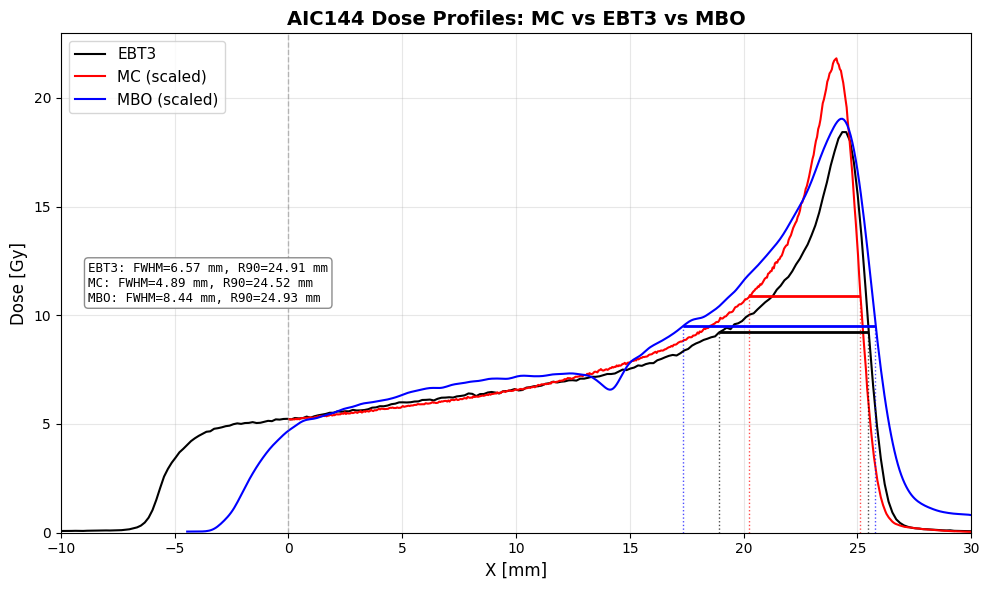

In [5]:
# Plotting function to reduce code duplication
def calc_fwhm_from_dense(x_dense, y_dense):
    """Calculate FWHM and return (left, right, value) or None."""
    half_max = y_dense.max() / 2
    above_half = y_dense >= half_max
    trans = np.diff(above_half.astype(int))
    rising, falling = np.where(trans == 1)[0], np.where(trans == -1)[0]
    if len(rising) > 0 and len(falling) > 0:
        return x_dense[rising[0]], x_dense[falling[-1]], x_dense[falling[-1]] - x_dense[rising[0]]
    return None

def find_90_percent_distal(x_dense, y_dense):
    """Find position where dose drops to 90% of max on distal edge."""
    threshold = 0.9 * y_dense.max()
    idx_max = np.argmax(y_dense)
    distal_mask = np.arange(len(x_dense)) > idx_max
    below = y_dense[distal_mask] < threshold
    if np.any(below):
        idx = np.where(below)[0][0]
        return x_dense[distal_mask][idx], y_dense[distal_mask][idx]
    return None, None

def plot_comparison(mbo_x, mbo_y, mbo_label, mbo_color, title_suffix):
    """Plot MC, EBT and MBO dose profiles with FWHM lines and metrics in box inset."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot profiles
    ax.plot(df_ebt['x_mm'], df_ebt['dose_Gy'], color='black', lw=1.5, label='EBT3')
    ax.plot(df_mc['depth'], df_mc['dose_scaled'], color='red', lw=1.5, label='MC (scaled)')
    ax.plot(mbo_x, mbo_y, color=mbo_color, lw=1.5, label=f'{mbo_label} (scaled)')
    ax.axvline(x=0, color='gray', ls='--', lw=1, alpha=0.5)
    
    # Prepare dense interpolations for FWHM/90% calculations
    profiles = [
        ('EBT3', df_ebt['x_mm'].values, df_ebt['dose_Gy'].values, 'black'),
        ('MC', df_mc['depth'].values, df_mc['dose_scaled'].values, 'red'),
        (mbo_label, mbo_x, mbo_y, mbo_color)
    ]
    
    # Collect metrics for box inset
    metrics_text = []
    
    for name, x, y, color in profiles:
        x_d = np.linspace(x.min(), x.max(), 1000)
        y_d = interp1d(x, y, fill_value='extrapolate')(x_d)
        
        # FWHM - draw lines only, no labels
        fwhm = calc_fwhm_from_dense(x_d, y_d)
        fwhm_val = fwhm[2] if fwhm else np.nan
        if fwhm:
            left, right, val = fwhm
            half_max = y_d.max() / 2
            ax.hlines(y=half_max, xmin=left, xmax=right, colors=color, lw=2)
            ax.vlines(x=[left, right], ymin=0, ymax=half_max, colors=color, ls=':', lw=1, alpha=0.7)
        
        # 90% distal position
        x_90, _ = find_90_percent_distal(x_d, y_d)
        range_90 = x_90 if x_90 is not None else np.nan
        
        # Collect metrics
        metrics_text.append(f"{name}: FWHM={fwhm_val:.2f} mm, R90={range_90:.2f} mm")
    
    # Add box inset with metrics (left middle)
    box_text = '\n'.join(metrics_text)
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    ax.text(0.03, 0.5, box_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='center', horizontalalignment='left',
            bbox=props, family='monospace')
    
    ax.set_xlabel('X [mm]', fontsize=12)
    ax.set_ylabel('Dose [Gy]', fontsize=12)
    ax.set_title(f'AIC144 Dose Profiles: MC vs EBT3 vs {title_suffix}', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-10, 30)
    ax.set_ylim(0, None)
    plt.tight_layout()
    plt.show()

# Generate comparison plot
plot_comparison(mbo_x_shifted, mbo_scaled, 'MBO', 'blue', 'MBO')

In [6]:
# Calculate profile parameters for summary table
def find_distal_position(x_dense, y_dense, threshold_fraction):
    """Find position on distal edge where dose drops to threshold_fraction of max."""
    threshold = threshold_fraction * y_dense.max()
    idx_max = np.argmax(y_dense)
    distal_mask = np.arange(len(x_dense)) > idx_max
    below = y_dense[distal_mask] < threshold
    if np.any(below):
        return x_dense[distal_mask][np.where(below)[0][0]]
    return np.nan

def calc_penumbra_80_20(x_dense, y_dense):
    """Calculate distance from 80% to 20% dose on distal edge."""
    x_80, x_20 = find_distal_position(x_dense, y_dense, 0.8), find_distal_position(x_dense, y_dense, 0.2)
    return x_20 - x_80 if not (np.isnan(x_80) or np.isnan(x_20)) else np.nan

def calc_fwhm(x_dense, y_dense):
    """Calculate FWHM."""
    half_max = y_dense.max() / 2
    above_half = y_dense >= half_max
    trans = np.diff(above_half.astype(int))
    rising, falling = np.where(trans == 1)[0], np.where(trans == -1)[0]
    return x_dense[falling[-1]] - x_dense[rising[0]] if len(rising) > 0 and len(falling) > 0 else np.nan

# Calculate for all profiles
profiles = {
    'EBT3': (df_ebt['x_mm'].values, df_ebt['dose_Gy'].values),
    'MC': (df_mc['depth'].values, df_mc['dose_scaled'].values),
    'MBO': (mbo_x_shifted, mbo_scaled)
}

results = []
for name, (x, y) in profiles.items():
    x_d = np.linspace(x.min(), x.max(), 1000)
    y_d = interp1d(x, y, fill_value='extrapolate')(x_d)
    dose_at_0 = float(interp1d(x, y, fill_value='extrapolate')(0))
    
    results.append({
        'Profile': name,
        'FWHM [mm]': f"{calc_fwhm(x_d, y_d):.2f}",
        'Range (90%) [mm]': f"{find_distal_position(x_d, y_d, 0.9):.2f}",
        'Max/Dose@X=0': f"{y_d.max() / dose_at_0:.3f}",
        'Penumbra 80-20% [mm]': f"{calc_penumbra_80_20(x_d, y_d):.2f}"
    })

df_summary = pd.DataFrame(results)
print("Profile Parameters Summary")
print("=" * 80)
display(df_summary)

Profile Parameters Summary


,Profile,FWHM [mm],Range (90%) [mm],Max/Dose@X=0,Penumbra 80-20% [mm]
0,EBT3,6.57,24.91,3.522,0.92
1,MC,4.89,24.52,4.171,0.93
2,MBO,8.44,24.93,4.056,1.42
